In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

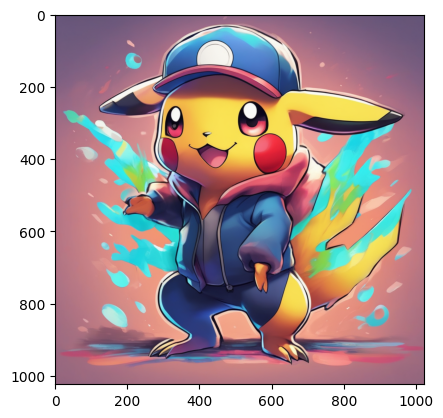

[[1024 1024]]


In [21]:
train_df= pd.DataFrame(pd.read_json("train.json"))
test_df= pd.DataFrame(pd.read_json("test.json"))

plt.imshow(Image.open(train_df.iloc[0]['image_path']))
plt.show()

sizes= []

for _, row in train_df.iterrows():
    sizes.append(Image.open(row['image_path']).size)
for _, row in test_df.iterrows():
    sizes.append(Image.open(row['image_path']).size)

print(np.unique(sizes, axis= 0))


In [22]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

transforms= EfficientNet_B0_Weights.DEFAULT.transforms()

model= efficientnet_b0(weights= EfficientNet_B0_Weights.DEFAULT)

model.classifier[1]= nn.Linear(model.classifier[1].in_features, 4)

In [23]:
from torch.utils.data import Dataset, DataLoader


label_to_idx={
    "Pokemon": 0,
    "Tarzan": 1,
    "Snow White": 2,
    "Winnie the Pooh":  3
}

class TrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df= df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path= self.df.iloc[idx]['image_path']
        label= self.df.iloc[idx]['cartoon_class']
        label= label_to_idx[label]
        
        img= Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label
    
train_dataset=TrainDataset(train_df, transform= transforms)

train_loader= DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


In [ ]:
import torch

device= 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr= 0.001)

for epoch in range(10):
    model.train()
    running_loss= 0.0

    for images, labels in train_loader:
        images, labels= images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs= model(images)
        loss= criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss+= loss.item()
    print(f"Epoch:{epoch+1}, Loss: {running_loss:.5f}")

Epoch:1, Loss: 3.46779
Epoch:2, Loss: 0.27851
Epoch:3, Loss: 0.17980
Epoch:4, Loss: 0.05001
Epoch:5, Loss: 0.29348
Epoch:6, Loss: 0.07081
Epoch:7, Loss: 0.41777
Epoch:8, Loss: 0.28196
Epoch:9, Loss: 0.32858
Epoch:10, Loss: 0.34748


: 

In [ ]:
class TestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df= df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path= self.df.iloc[idx]['image_path']
        img= Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img

test_dataset= TestDataset(test_df, transform= transforms)

test_loader= DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

predictions= []

model.eval()

with torch.no_grad():
    for images in test_loader:
        images= images.to(device)
        outputs= model(images)
        preds= torch.argmax(outputs, 1)
        predictions.extend(preds.cpu().numpy())

answer = []

idx_to_label={
    0: "Pokemon",
    1: "Tarzan",
    2: "Snow White",
    3: "Winnie the Pooh"
}

for idx, row in test_df.iterrows():
    answer.append({
        "image_path": row['image_path'],
        "cartoon_class": idx_to_label[predictions[idx]]
    })
pd.DataFrame(answer).to_csv("submission.csv", index= False)